# **1. Perkenalan Dataset**


**Dataset yang digunakan: Vehicle Sales Data (prediksi harga jual kendaraan)**

1. **Sumber & tautan:** [Kaggle — Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data) (user: `syedanwarafridi`).
2. **File utama:** `car_prices.csv` (≈88 MB, **16 kolom**), diunduh lewat Kaggle API di Google Colab atau diletakkan manual di folder kerja.
3. **Variabel target (harga):** biasanya kolom `sellingprice` (atau ekuivalen di CSV Anda — dicek otomatis di kode memuat data).

*Tugas Anda melengkapi narasi insight di bagian EDA setelah menjalankan sel kode.*


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Deteksi lingkungan Colab vs lokal
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj)


DATASET_SLUG = "syedanwarafridi/vehicle-sales-data"
ZIP_NAME = "vehicle-sales-data.zip"
CSV_CANDIDATES = ("car_prices.csv", "dataset.csv")


def ensure_kaggle_credentials_colab() -> None:
    """Pasang kaggle.json di Colab (unggah token dari Kaggle → Account → API)."""
    kaggle_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.isfile(kaggle_path):
        return
    if not IN_COLAB:
        raise FileNotFoundError(
            "Letakkan ~/.kaggle/kaggle.json atau file CSV data di folder kerja."
        )
    from google.colab import files

    print("Unggah kaggle.json dari Kaggle (Create New Token)...")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    for name in uploaded:
        if name.endswith(".json"):
            dest = os.path.expanduser("~/.kaggle/kaggle.json")
            with open(name, "rb") as src, open(dest, "wb") as dst:
                dst.write(src.read())
            os.chmod(dest, 0o600)
            break
    if not os.path.isfile(kaggle_path):
        raise FileNotFoundError("kaggle.json tidak ditemukan setelah unggah.")


def download_kaggle_dataset() -> None:
    if os.path.isfile(ZIP_NAME):
        return
    ensure_kaggle_credentials_colab()
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kaggle"],
        check=False,
    )
    dl = subprocess.run(
        ["kaggle", "datasets", "download", "-d", DATASET_SLUG],
        capture_output=True,
        text=True,
    )
    if dl.returncode != 0:
        raise RuntimeError(
            "Gagal mengunduh dataset dari Kaggle.\n"
            + (dl.stderr or dl.stdout or "")
        )
    subprocess.run(["unzip", "-o", ZIP_NAME], check=False)


def resolve_csv_path() -> str:
    for name in CSV_CANDIDATES:
        if os.path.isfile(name):
            return name
    if IN_COLAB:
        download_kaggle_dataset()
        for name in CSV_CANDIDATES:
            if os.path.isfile(name):
                return name
    raise FileNotFoundError(
        f"Tidak menemukan CSV. Letakkan salah satu: {CSV_CANDIDATES} atau jalankan di Colab dengan Kaggle API."
    )


csv_path = resolve_csv_path()
df = pd.read_csv(csv_path)
print(f"Membaca: {csv_path} | bentuk: {df.shape[0]:,} baris × {df.shape[1]} kolom")
display(df.head())
print("\nInfo kolom & tipe:")
df.info()

Unggah kaggle.json dari Kaggle (Create New Token)...


Saving kaggle.json to kaggle.json
Membaca: car_prices.csv | bentuk: 558,837 baris × 16 kolom


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)



Info kolom & tipe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

,missing,missing_%
transmission,65352,11.69
body,13195,2.36
condition,11820,2.12
trim,10651,1.91
model,10399,1.86
make,10301,1.84
color,749,0.13
interior,749,0.13
odometer,94,0.02
mmr,38,0.01


Baris duplikat (full row): 0
Kolom target dipakai: sellingprice


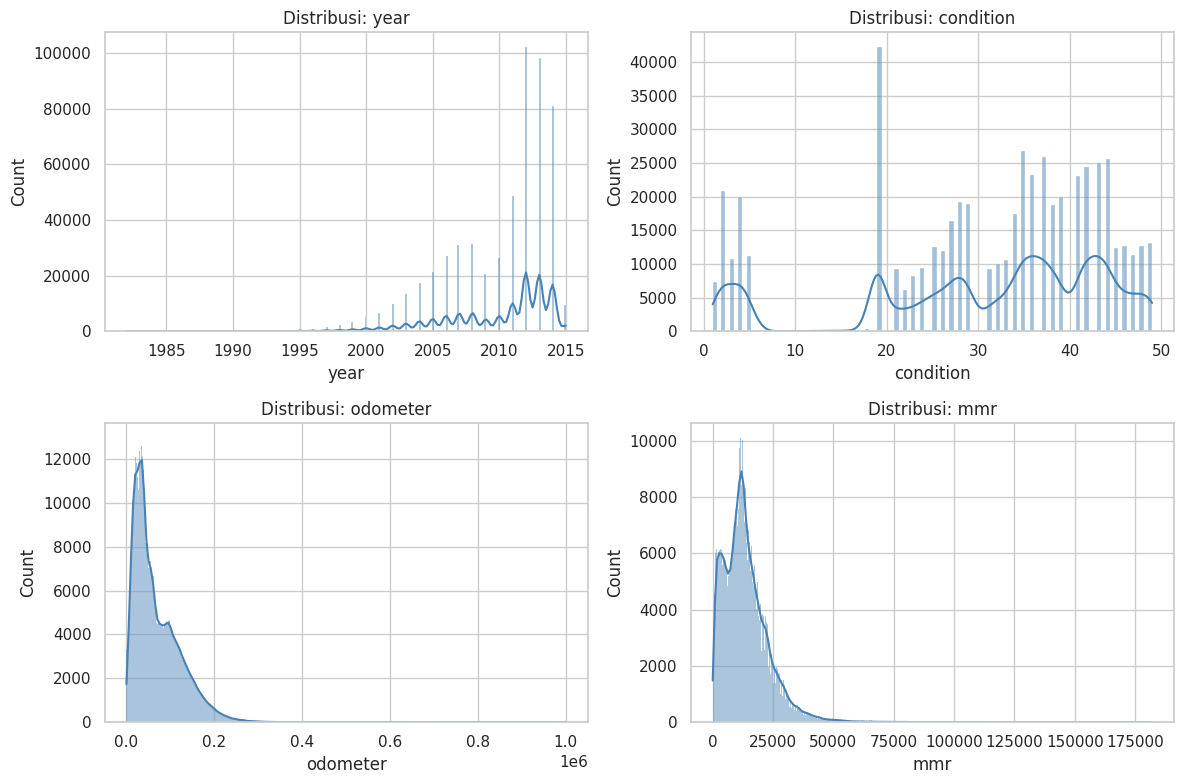

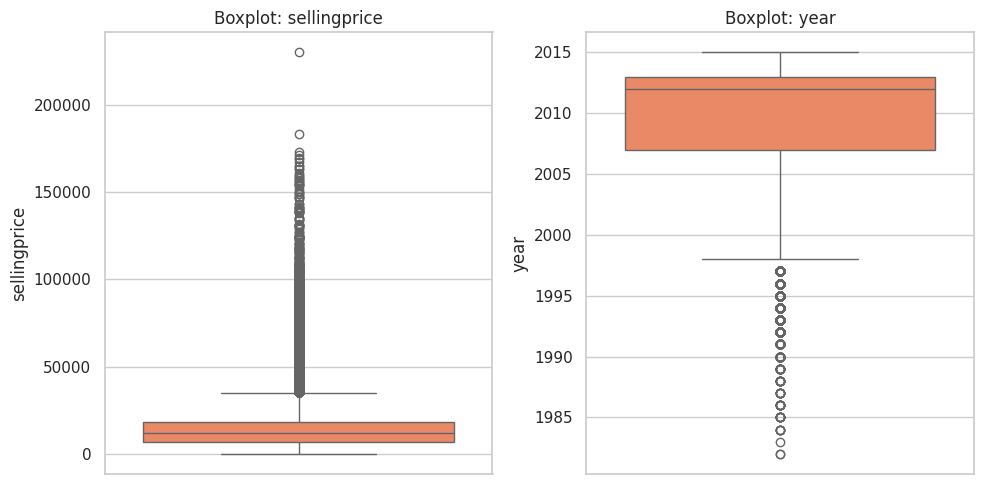

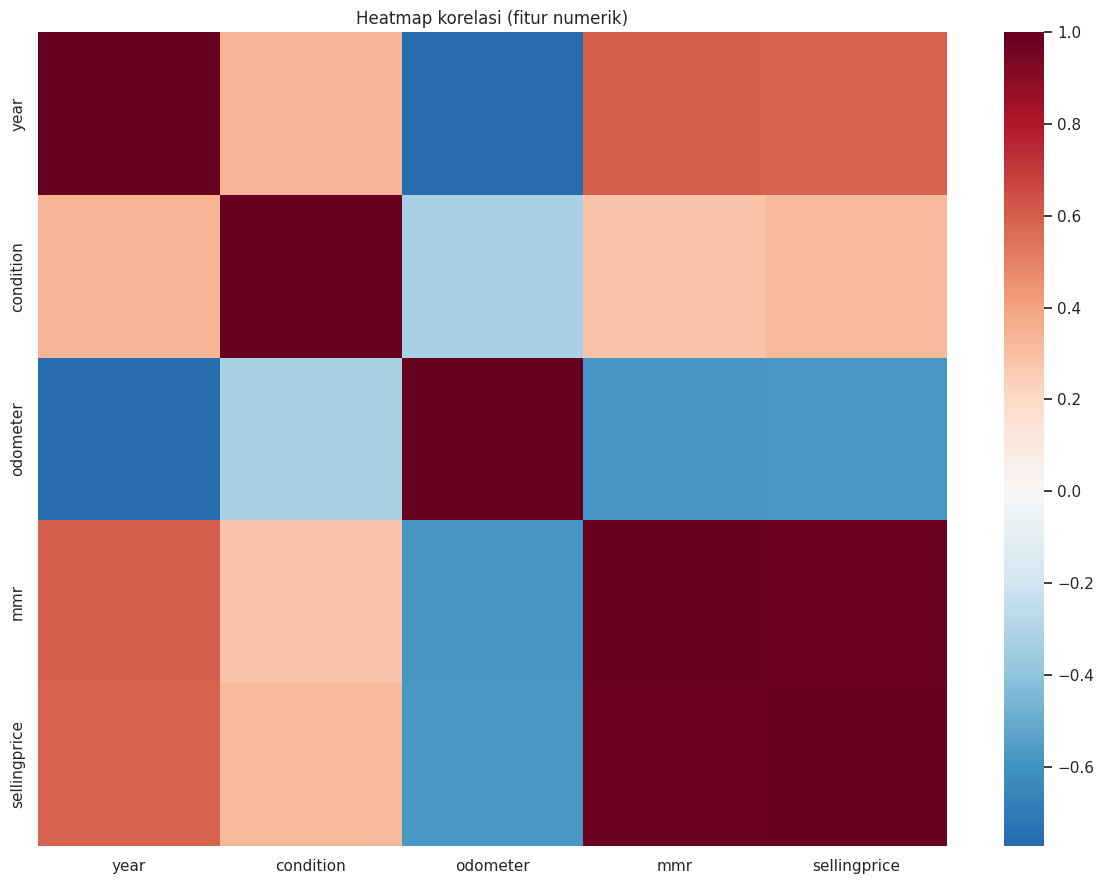


--- Isi insight di sel Markdown berikutnya: pola missing value, outlier pada harga, korelasi kuat dengan harga, dan implikasi untuk preprocessing.---


In [ ]:
# --- Ringkasan kualitas data ---
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
qual = pd.DataFrame({"missing": missing, "missing_%": missing_pct})
display(qual[qual["missing"] > 0])

# Duplikat
dup_n = df.duplicated().sum()
print(f"Baris duplikat (full row): {dup_n:,}")

# Target harga: sesuaikan nama kolom jika dataset berubah
TARGET_CANDIDATES = ["sellingprice", "saleprice", "price", "SellingPrice"]
target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise KeyError(f"Tidak menemukan kolom target. Kolom tersedia: {df.columns.tolist()}")
print(f"Kolom target dipakai: {target_col}")

# Numerik untuk korelasi / plot
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    key_numeric = [c for c in num_cols if c != target_col][:8]
else:
    key_numeric = num_cols[:8]

# Histogram beberapa fitur numerik + target
n = min(4, len(key_numeric) + 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
plot_cols = (key_numeric + [target_col])[:4]
for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribusi: {col}")
plt.tight_layout()
plt.show()

# Boxplot target + satu fitur numerik lain (jika ada)
box_cols = [target_col] + ([key_numeric[0]] if key_numeric else [])
fig, axes = plt.subplots(1, len(box_cols), figsize=(5 * len(box_cols), 5))
if len(box_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, box_cols):
    sns.boxplot(y=df[col], ax=ax, color="coral")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

# Heatmap korelasi (fitur numerik)
if len(num_cols) >= 2:
    plt.figure(figsize=(12, 9))
    corr = df[num_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
    plt.title("Heatmap korelasi (fitur numerik)")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom numerik terlalu sedikit untuk heatmap.")

### Ringkasan insight EDA

- **Missing values:** Data terdiri dari **558.837 baris × 16 kolom**, tanpa **duplikat baris penuh**. Nilai kosong terbanyak pada **`transmission`** (~65.352 baris, ~11,7%), diikuti **`body`** (~13k), **`condition`** (~12k), **`trim`**, **`model`**, dan **`make`** (masing-masing sekitar 10k–11k). Lebih ringan pada **`color`** / **`interior`** (~749), **`odometer`** (94), **`mmr`** (38), serta sangat sedikit pada **`sellingprice`** / **`saledate`** (12) dan **`vin`** (4). Baris tanpa harga jual perlu dibuang atau diimputasi sebelum pemodelan.

- **Outlier / distribusi harga:** **`sellingprice`** distribusinya **menceng ke kanan**: median **12.100** vs mean **13.611** (USD), minimum **1** dan maksimum **230.000**. Dengan kriteria **IQR**, sekitar **2,9%** titik data berada di luar “kumis” boxplot — mencakup harga sangat rendah/tinggi. Untuk regresi, skew ini mendukung penggunaan model yang tahan non-linearitas atau transformasi/log (opsional).

- **Korelasi penting:** Korelasi Pearson ke **`sellingprice`** pada fitur numerik: **`mmr` sangat tinggi positif (~0,98)** — nilai pasar grosir sangat selaras dengan harga jual; **`year`** moderat positif (**~0,59**); **`odometer`** moderat negatif (**~−0,58**); **`condition`** lemah–moderat positif (**~0,32**). Heatmap memperkuat bahwa usia/km/kondisi dan penanda nilai pasar bergerak searah dengan harga.

- **Keputusan preprocessing:** (1) **Drop** baris tanpa target **`sellingprice`**; (2) **imputasi** — median untuk numerik, modus untuk kategori (sesuai pipeline); (3) **hapus `vin`** (pengenal unik) dan **`saledate`** mentah kecuali diubah jadi fitur waktu; (4) **encoding** one-hot (dengan batas kategori) + **standarisasi** numerik; (5) **`mmr`**: secara substansi mirip “jawaban” harga — jika tugas menekankan prediksi dari atribut kendaraan saja, pertimbangkan **menjatuhkan `mmr`** untuk mengurangi *leakage*; jika fokus akurasi bisnis dengan sinyal pasar, boleh **dipertahankan** dan disebutkan di laporan; (6) outlier ekstrem boleh **dibiarkan** dengan model berbasis pohon/gradient boosting atau **dibatasi (cap/winsorize)** bila diperlukan stabilitas.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor

# --- Salin data agar df EDA tetap utuh ---
df_model = df.copy()

TARGET_CANDIDATES = ["sellingprice", "saleprice", "price", "SellingPrice"]
target_col = next((c for c in TARGET_CANDIDATES if c in df_model.columns), None)
if target_col is None:
    raise KeyError(
        "Kolom target harga tidak ditemukan. Kolom: " + str(df_model.columns.tolist())
    )

# Duplikat & baris tanpa target
df_model = df_model.drop_duplicates()
df_model = df_model.dropna(subset=[target_col])

y = df_model[target_col]
X = df_model.drop(columns=[target_col])

# VIN = pengenal unik; saledate mentah — buang atau ubah jadi fitur tanggal di tugas lanjutan
for col in ("vin", "saledate"):
    if col in X.columns:
        X = X.drop(columns=[col])

# Subsample untuk Colab (None = pakai semua baris; risiko OOM jika RAM kecil)
SAMPLE_MAX = 150_000
if SAMPLE_MAX is not None and len(X) > SAMPLE_MAX:
    X = X.sample(n=SAMPLE_MAX, random_state=42)
    y = y.loc[X.index]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                max_categories=25,
            ),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    sparse_threshold=0.3,
)

model = Pipeline(
    steps=[
        ("prep", preprocess),
        (
            "reg",
            HistGradientBoostingRegressor(
                max_depth=12,
                learning_rate=0.08,
                max_iter=300,
                random_state=42,
            ),
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = float(np.sqrt(mse))
r2 = r2_score(y_test, pred)
print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MODEL_PATH = "model.joblib"
joblib.dump(model, MODEL_PATH)
print(f"Model disimpan ke: {MODEL_PATH}")